# Estudando a biblioteca `NetworkX`
NetworkX é um pacote Python utilizado para manipulação de grafos e redes complexas. 

## Criando um objeto networkx
Como apresentado anteriormente, um grafo é composto por vértices conectados por arestas. NetworkX permite que vértices possam ser strings de texto, números, etc.

O código a seguir cria um objeto networkx:

In [1]:
import networkx as nx
G = nx.Graph()

## Adicionando vértices
Agora vamos adicionar dois vértices e criar uma aresta para conectá-los:

In [19]:
# adicionando vertices
G.add_node(1)
G.add_node(2)


# Visualizando os vertices
print(G.nodes())
 #[1, 2]

#adicionando arestas
G.add_edge(1, 2)

# total de vertices e arestas
n_vertices = G.number_of_nodes()
n_arestas = G.number_of_edges()

print('vertices: ', n_vertices, '\narestas: ', n_arestas)

#Networkx irá criar os vértices 4 e 5, e depois irá criar uma aresta os conectando.
#Usando add_edge_from, podemos adicionar várias arestas de uma vez, e o Networkx irá criar os vértices que ainda não existirem.
G.add_edge(4, 5)
print(G.nodes()) # [4, 5]

#Você pode visualizar as arestas acessando o atributo edges:
print(G.edges()) # [(1, 2), (4, 5)]

[2, 4, 5, 1]
vertices:  4 
arestas:  1
[2, 4, 5, 1]
[(2, 1), (4, 5)]


## Removendo vértices
Podemos remover um vértice usando a função remove_node( ):

In [20]:
# remove o nó 1
G.remove_node(1)
# Ele retira tanto o nó, quanto as arestas em que o nó era terminal
print(G.nodes()) # [2, 4, 5]
print(G.edges()) # [(4, 5)]

[2, 4, 5]
[(4, 5)]


## Desenhando o grafo
Podemos imprimir o grafo usando o comando draw. Veja:
* with_labels=True -> mostra os rótulos dos nós
* node_color -> cor dos nós
* node_size -> tamanho dos nós
* font_size -> tamanho da fonte dos rótulos
* font_color -> cor da fonte dos rótulos
* font_weight -> peso da fonte dos rótulos
* edge_color -> cor das arestas
* edgecolors -> cor das bordas dos nós
* horizontalalignment/vertical -> controla o posicionamento da label dentro do vertice

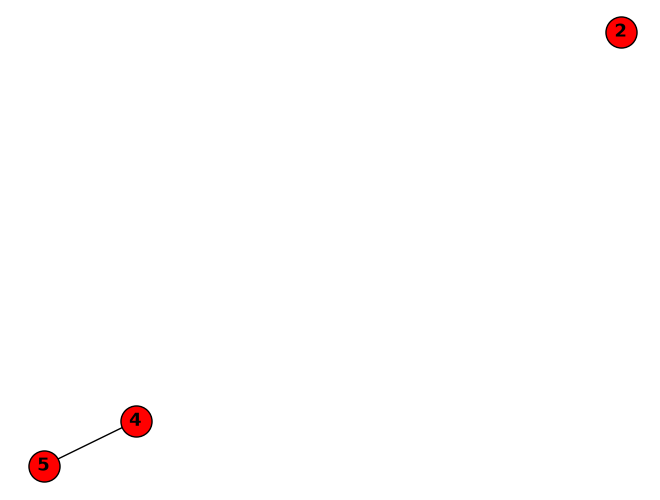

In [15]:
nx.draw(G, with_labels=True, node_color='red', node_size=500, font_size=13, font_color='black', font_weight='bold', edge_color='black', edgecolors='black', verticalalignment='center', horizontalalignment='center', alpha=1)

## Subgrafos
Na figura apresentada acima, podemos perceber visualmente que há duas partes do grafo que não se conectam entre si. Denominamos essas partes como subgrafos. Podemos obtê-las utilizando o código:

In [30]:

G.add_edges_from([
    (1,3),
    (1,4),
    (1,2),
    (1,8),
    (8,7),
    (5,6),
    (5,9)
])

subgrafo = [G.subgraph(c) for c in nx.connected_components(G)]
print(len(subgrafo)) # 2
print(subgrafo[0].nodes()) # [2]
print(subgrafo[1].nodes()) # [4, 5]
nx.a

2
[2, 4, 1, 3, 8, 7]
3


## Variações do draw
A definição da posição de impressão é aleatória. Entretanto, podemos utilizar algumas variações da função draw para alterar a forma de plotagem. Vamos ilustrar isso usando duas dessas variações: draw_circular e draw_random.

Note pelo exemplo acima que a função draw_circular força os vértices a se posicionarem em forma de círculo. A outra função, draw_random, posiciona os pontos de forma aleatória.

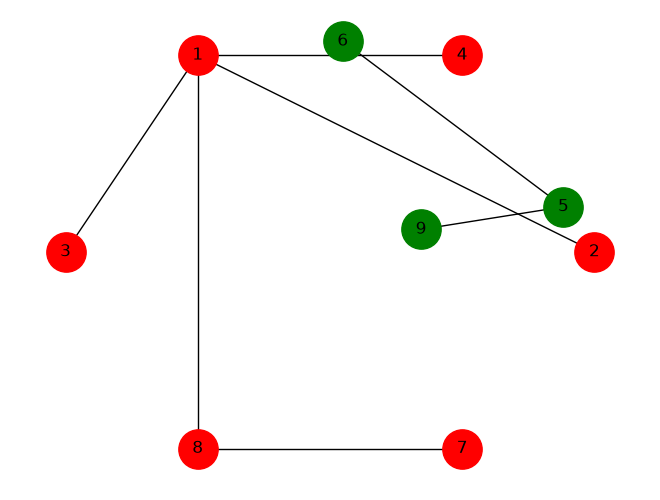

In [29]:
# grafo vermelho - circular
nx.draw_circular(
    subgrafo[0], 
    with_labels=True, 
    node_size=800, 
    node_color='red'
)

# grafo verde - posições aleatórias
nx.draw_random(
    subgrafo[1], 
    with_labels=True, 
    node_size=800, 
    node_color='green'
)

## Calculando as metricas de centralidade
* Cetralidade de grau: `nx.degree_centrality(G)`
* Centralidade de proximidade: `nx.closeness_centrality(G)`
* Centralidade de intermediação: `nx.betweenness_centrality(G)`
* Centralidade de autovertor: `nx.eigenvector_centrality(G)`

o NetworkX já calcula, só precisa passar o grafo.
Retorna um dicionário, em que a chave é o nó (vértice) e o valor é a centralidade dele.

## Algoritmo de Louvain
Em redes reais, os nós costumam se agrupar. Num grafo de amizades, por exemplo, surgem grupos de colegas de trabalho, família, time de futebol. O Louvain encontra esses grupos automaticamente, sem você dizer quantos são nem quais são.

Ele usa a modularidade (Q), uma medida que compara quantas arestas existem dentro das comunidades com quantas seriam esperadas se as conexões fossem aleatórias. Quanto maior o Q (vai até 1), mais bem definida é a divisão. O algoritmo tenta maximizar esse valor.
* Q próximo de 0: a divisão não é melhor do que a aleatória.
* Q negativo: pior do que o acaso
* Q entre 0,3 e 0,7: em geral indica estrutura de comunidades clara

Uso em `redes sociais`: achar grupos de afinidade

In [36]:
from networkx.algorithms.community import louvain_communities, modularity

#Função interessante nx.karate_club_graph() - retorna um grafo de exemplo do clube de karatê de Zachary.
graph_louvain = nx.karate_club_graph()
#Como louvain é aleatorio, podemos definir uma seed para que o resultado seja sempre o mesmo.
comunidades = louvain_communities(graph_louvain, seed=42)
print(comunidades)

[{16, 4, 5, 6, 10}, {0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21}, {23, 24, 25, 27, 28, 31}, {32, 33, 8, 9, 14, 15, 18, 20, 22, 26, 29, 30}]
